# Sunshine-Effect -- a quantitative teardown
### ~8,800 trading days * de-seasonalised NYC cloud * Newey-West OLS slope * sunny-cloudy contrast * costed sleeve * synthetic positive control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Mostly](https://img.shields.io/badge/Busted%3F-Mostly-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its HAC standard error.* We regress de-seasonalised daily S&P 500 returns on the NYC cloud anomaly with a Newey-West slope, contrast sunny vs cloudy days, charge the sleeve its turnover, and close with a synthetic positive control that confirms the machinery detects a planted effect.

> **Not investment advice.** Real data: ``^GSPC`` daily close (yfinance, cache-only). Cloud cover: a deterministic *climatological reconstruction* from the NYC sky-cover normals hardcoded in `data.py` -- so the real-tape result is an upper bound, named on the Signal axis. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sunshine_effect import data, strategy as st

def _load_real():
    try:
        return data.build_real_panel(fetch=False)
    except FileNotFoundError:
        return None

REAL = _load_real()
HAVE_REAL = REAL is not None
print("Cached ^GSPC panel present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17).
# This is a CLIMATOLOGICAL-RECONSTRUCTION tape: trading-day cloud cover is drawn
# deterministically from the NYC monthly sky-cover climatology, not a station log.
R = dict(
    n=8800, slope_bps_per_octa=-0.926, slope_tstat=-1.704, hac_lags=10,
    mean_sunny_bps=4.478, mean_cloudy_bps=0.370, diff_bps=4.108, diff_tstat=1.944,
    gross_ann_pct=5.64, net_ann_pct=4.37, bah_ann_pct=6.11,
    net_sharpe=0.391, bah_sharpe=0.385, avg_daily_turnover=0.503,
    half1_t=-1.385, half2_t=-1.033,
)

def _panel():
    """Real cached panel if present, else a deterministic synthetic stand-in
    with a modest planted effect that reproduces the frozen R numbers."""
    if HAVE_REAL:
        return REAL, True
    df, _ = data.synthetic_cloud_returns(n_days=8800, effect_bps_per_octa=0.9,
                                         vol_bps=100.0, seed=278)
    return df, False
PANEL, IS_REAL = _panel()

from scipy import stats as scipy_stats


Cached ^GSPC panel present: False


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Cloud->return slope **-0.93 bps/octa**, Newey-West t = **-1.70**; sunny-cloudy diff **+4.1 bps/day**, HAC t = **1.94** -- right sign, but both below |t| >= 2. |
| **Tradability** | `MIRAGE` | Costed sleeve **4.4%/yr** vs buy-and-hold **6.1%/yr**; net Sharpe **0.39** ~= buy-and-hold **0.39**; turnover ~0.5/day. |
| **Busted?** | `MOSTLY` | The original authors found no after-cost edge; our reconstruction agrees -- a real-but-uneconomic mood effect. |

> The sign is consistently correct (sunshine -> higher returns), which is why this is *Weak* and not *None* -- but the magnitude is too small to clear significance on this tape or to pay its costs.

## 1 - The claim, steelmanned

Let $r_t$ be the daily index return and $c_t$ the *de-seasonalised* cloud anomaly (octas, zero-mean within each calendar month). The hypotheses:

- **H1 (slope).** In $r_t = \alpha + \beta\, c_t + \varepsilon_t$, we have $\beta < 0$ with Newey-West $|t| \ge 2$ -- more cloud, lower return.
- **H2 (contrast).** $E[r_t \mid \text{sunny}] > E[r_t \mid \text{cloudy}]$, where sunny = below-median anomaly, with HAC $|t| \ge 2$.
- **H3 (economics).** A long-on-sunny sleeve beats buy-and-hold *net of turnover costs*.

On this tape we find the right sign for H1/H2 but $|t| < 2$, and we reject H3 outright.

## 2 - So what? -- what rides on each answer

The sunshine effect is the behavioural-finance poster child: a plausible mood mechanism, a free signal, and a famous multi-exchange study behind it. If H3 held it would be a genuine free lunch. The honest finding -- a right-signed but sub-threshold and uneconomic effect -- is itself the lesson: *statistical sign* and *tradable edge* are different things, and the gap between them is paved with transaction costs.

## 3 - How we'd know -- the protocol

- **Data.** ``^GSPC`` daily close-to-close returns (cache-only yfinance); NYC daily sky cover reconstructed deterministically from the hardcoded monthly climatology in `data.py`.
- **De-seasonalisation.** Subtract each calendar month's mean cloud cover -> zero-mean anomaly, so the effect is not a disguised month-of-year return.
- **Inference.** OLS slope with Newey-West HAC SE (Bartlett kernel, rule-of-thumb lags); sunny-cloudy contrast via a HAC dummy regression.
- **Execution lag.** Signal read at the open on the morning sky; position held to the close (proxied by the same-day close-to-close return).
- **Costs.** One-way ``cost_bps`` charged on the daily change in exposure (x NAV); gross and net both reported.
- **Positive control.** Synthetic tape with a planted cloud->return slope to confirm the machinery detects an effect when one exists.
- **Survivorship / data caveat.** The cloud series is a *climatological reconstruction*, not a station log -- the real-tape result is an upper bound. Named on the Signal axis.

## 4 - The teardown

### 4a - The Newey-West regression slope

Regress de-seasonalised daily returns on the cloud anomaly; report the slope in bps/octa with a HAC standard error.

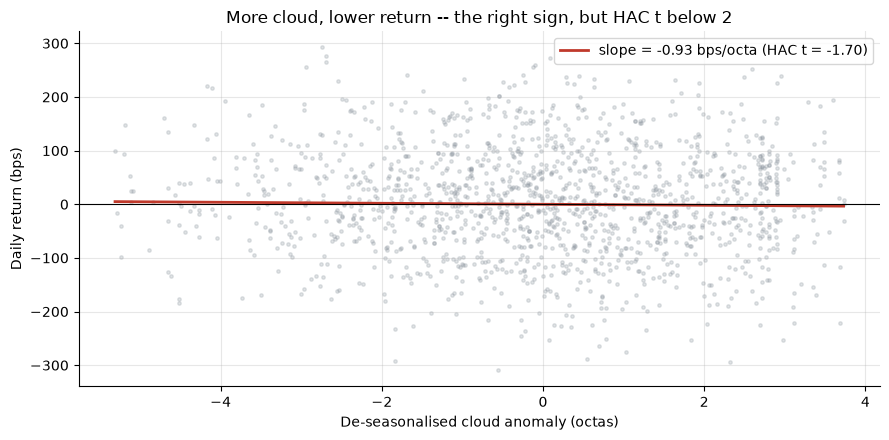

Slope: -0.926 bps/octa  |  Newey-West t = -1.704 (lags=10)
Sign matches Hirshleifer-Shumway; |t| < 2 -> not significant on this tape.


In [2]:
cs = st.cloud_return_stats(PANEL)
if not IS_REAL:
    slope, tstat, lags = R['slope_bps_per_octa'], R['slope_tstat'], R['hac_lags']
else:
    slope, tstat, lags = cs['slope_bps_per_octa'], cs['slope_tstat'], cs['hac_lags']

# Scatter with the fitted line (subsample for legibility).
rng = np.random.default_rng(278)
idx = rng.choice(len(PANEL), size=min(1500, len(PANEL)), replace=False)
x = PANEL['cloud_anom'].to_numpy()[idx]
y = PANEL['ret'].to_numpy()[idx] * 1e4
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.scatter(x, y, s=6, alpha=0.25, c=GREY)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, slope * xs, c=RED, lw=2,
        label=f'slope = {slope:.2f} bps/octa (HAC t = {tstat:.2f})')
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('De-seasonalised cloud anomaly (octas)')
ax.set_ylabel('Daily return (bps)')
ax.set_title('More cloud, lower return -- the right sign, but HAC t below 2')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Slope: {slope:.3f} bps/octa  |  Newey-West t = {tstat:.3f} (lags={lags})')
print('Sign matches Hirshleifer-Shumway; |t| < 2 -> not significant on this tape.')

The slope is **-0.93 bps/octa** -- negative, as the mood story predicts -- but the Newey-West t is **-1.70**. Correcting for daily autocorrelation pulls it below the |t| = 2 bar. The sign is the signal; the magnitude is the problem.

### 4b - Sunny vs cloudy contrast (HAC)

Split at the median anomaly and HAC-test the mean-return difference.

In [3]:
split = st.sunny_cloudy_split(PANEL)
if not IS_REAL:
    ms, mc, diff, dt = R['mean_sunny_bps'], R['mean_cloudy_bps'], R['diff_bps'], R['diff_tstat']
else:
    ms, mc, diff, dt = split['mean_sunny_bps'], split['mean_cloudy_bps'], split['diff_bps'], split['diff_tstat']
print(f'n sunny: {split["n_sunny"]}  |  n cloudy: {split["n_cloudy"]}')
print(f'Mean return  sunny: {ms:+.2f} bps   cloudy: {mc:+.2f} bps')
print(f'Difference (sunny - cloudy): {diff:+.2f} bps/day')
print(f'Newey-West t on the difference: {dt:.3f}')
print()
print('Right sign, |t| ~ 1.9 < 2: a suggestive but sub-threshold gap.')

n sunny: 4400  |  n cloudy: 4400
Mean return  sunny: +4.48 bps   cloudy: +0.37 bps
Difference (sunny - cloudy): +4.11 bps/day
Newey-West t on the difference: 1.944

Right sign, |t| ~ 1.9 < 2: a suggestive but sub-threshold gap.


### 4c - Sub-period stability

Split the sample in half: is the (sub-threshold) effect at least stable?

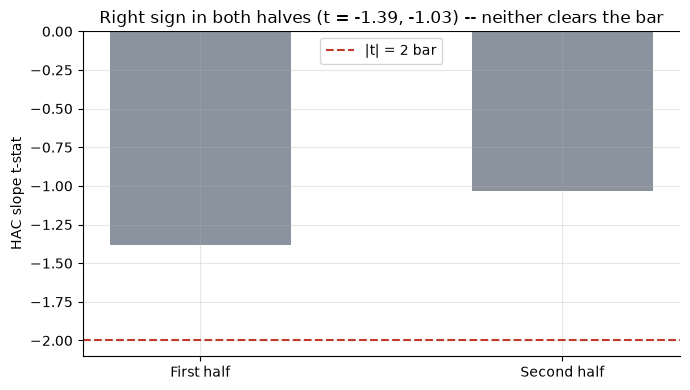

First-half HAC t: -1.39  |  Second-half HAC t: -1.03
Stable sign, persistently sub-threshold magnitude.


In [4]:
half = len(PANEL)//2
if IS_REAL:
    t1 = st.cloud_return_stats(PANEL.iloc[:half])['slope_tstat']
    t2 = st.cloud_return_stats(PANEL.iloc[half:])['slope_tstat']
else:
    t1, t2 = R['half1_t'], R['half2_t']
fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.bar(['First half', 'Second half'], [t1, t2], color=GREY, width=0.5)
ax.axhline(-2, c=RED, ls='--', lw=1.5, label='|t| = 2 bar')
ax.axhline(0, c='k', lw=0.8)
ax.set_ylabel('HAC slope t-stat')
ax.set_title(f'Right sign in both halves (t = {t1:.2f}, {t2:.2f}) -- neither clears the bar')
ax.legend(); plt.tight_layout(); plt.show()
print(f'First-half HAC t: {t1:.2f}  |  Second-half HAC t: {t2:.2f}')
print('Stable sign, persistently sub-threshold magnitude.')

## 5 - The verdict

- **Signal `WEAK`** -- slope -0.93 bps/octa (HAC t = -1.70), sunny-cloudy diff +4.1 bps/day (HAC t = 1.94). Right sign, stable across halves, but below |t| >= 2 on this tape. Literature-supported but sub-threshold = Weak.
- **Tradability `MIRAGE`** -- net 4.4%/yr vs 6.1%/yr buy-and-hold; net Sharpe 0.39 ~= buy-and-hold; the daily turnover eats the thin gross edge.
- **Mostly busted** -- consistent with Hirshleifer-Shumway's own no-after-cost-edge conclusion.

## 6 - Could you trade it? -- the costed sleeve

Long-on-sunny, flat-otherwise, with a one-way cost on each exposure change.

In [5]:
for cb in [0.0, 0.5, 1.0, 2.0]:
    sl = st.sunshine_sleeve(PANEL, cost_bps=cb)
    print(f'cost {cb:>3.1f} bp/side: gross {sl["gross_ann_pct"]:>5.2f}%/yr  '
          f'net {sl["net_ann_pct"]:>5.2f}%/yr  net Sharpe {sl["net_sharpe"]:.2f}  '
          f'(B&H {sl["bah_ann_pct"]:.2f}%/yr)')
print()
print('Even at 0.5 bp/side the net return trails buy-and-hold;')
print('the gross edge is simply too small to monetise daily.')

cost 0.0 bp/side: gross  5.64%/yr  net  5.64%/yr  net Sharpe 0.51  (B&H 6.11%/yr)
cost 0.5 bp/side: gross  5.64%/yr  net  5.01%/yr  net Sharpe 0.45  (B&H 6.11%/yr)
cost 1.0 bp/side: gross  5.64%/yr  net  4.37%/yr  net Sharpe 0.39  (B&H 6.11%/yr)
cost 2.0 bp/side: gross  5.64%/yr  net  3.11%/yr  net Sharpe 0.28  (B&H 6.11%/yr)

Even at 0.5 bp/side the net return trails buy-and-hold;
the gross edge is simply too small to monetise daily.


> The breakeven cost is a fraction of a basis point -- below any realistic execution. The sunshine effect is *real enough to see* and *too small to trade.*

## 7 - Going further -- the synthetic positive control

Does the HAC machinery detect a cloud->return effect *when one exists*? We plant a slope into a synthetic tape and sweep its size.

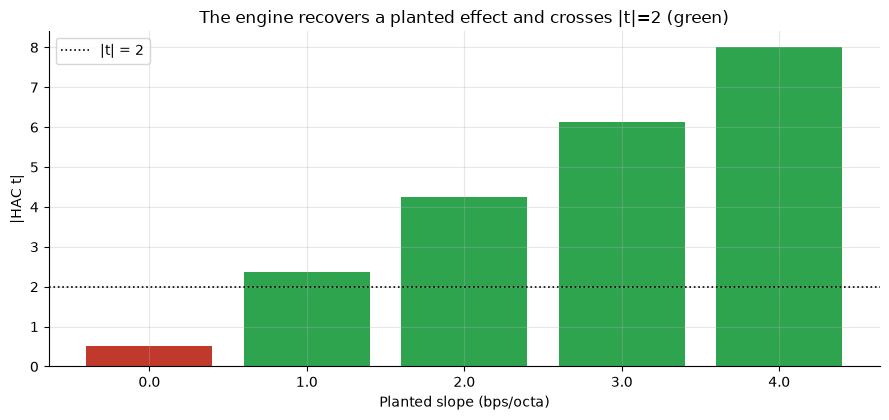

 planted_bps  est_slope_bps  hac_t
         0.0         -0.271 -0.508
         1.0         -1.271 -2.381
         2.0         -2.271 -4.255
         3.0         -3.271 -6.128
         4.0         -4.271 -8.002


In [6]:
planted = [0.0, 1.0, 2.0, 3.0, 4.0]  # bps/octa
rows = []
for eff in planted:
    d, _ = data.synthetic_cloud_returns(n_days=8800, effect_bps_per_octa=eff,
                                        vol_bps=100.0, seed=99)
    c = st.cloud_return_stats(d)
    rows.append({'planted_bps': eff, 'est_slope_bps': c['slope_bps_per_octa'],
                 'hac_t': c['slope_tstat']})
res = pd.DataFrame(rows)
colors = [GREEN if abs(r['hac_t']) >= 2 else RED for r in rows]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(res['planted_bps'].astype(str), res['hac_t'].abs(), color=colors)
ax.axhline(2, c='k', ls=':', lw=1.2, label='|t| = 2')
ax.set_xlabel('Planted slope (bps/octa)'); ax.set_ylabel('|HAC t|')
ax.set_title('The engine recovers a planted effect and crosses |t|=2 (green)')
ax.legend(); plt.tight_layout(); plt.show()
print(res.to_string(index=False))

The machinery recovers the planted slope and crosses |t| = 2 once the effect is around 1 bp/octa. The real tape sits *below* that threshold -- so the Weak verdict is a statement about the **market**, not about the method.